# Introduction to K means

K-means clustering is an unsupervised machine learning algorithm that groups unlabeled data into a predefined number of clusters. It is one of the most popular clustering algorithms due to its simplicity and effectiveness.


![K-means](https://miro.medium.com/v2/resize:fit:640/format:webp/0*VaT0CgPcagwFX1Az.png)


---
##1.&nbsp; Import libraries and files 💾

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ID of the Google Sheet for student food preferences
sheet_id = "1gYXqOBLEYIr99YmKGq2nIvK3CJmoWzsvwfwR9adfo2w"

# Title of the Google Sheet
sheet_name = "18136796"

# URL to download the Google Sheet as a CSV
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_name}"

# Create a Pandas DataFrame from the CSV data
foods_df = pd.read_csv(url,
                       index_col="student")

# Drop age - we only care about food here (we'll use age when we learn to scale data)
# Drop favorite_color - why can't we use a color to calculate distances
to_drop = ['age', 'favorite_color']
foods_df = foods_df.drop(columns=to_drop)

---
##2.&nbsp; Explore the data 👩‍🚀

In [ ]:
foods_df

,broccoli,brussels_sprouts,hamburger (meat),oysters (raw),onion (raw),peas,olives,blue_cheese,whisky
student,,,,,,,,,
Alexandra,10,10,10,10,10,7,6,10,0
Andrea,10,10,1,1,10,9,10,4,2
Daniel,10,10,10,0,3,10,10,10,10
Josef,3,3,9,9,5,5,8,10,7
Kaj,3,10,7,8,8,10,8,10,9
Katherine,5,0,9,5,10,8,10,5,8
Leslie,7,3,3,5,3,7,7,5,1
Merry,8,5,0,0,2,9,8,0,4
Perry,8,0,5,0,0,8,4,0,0


What kind of foods do you all like the most?

In [ ]:
# Calculate the average score for each column
average_scores = foods_df.mean()

# Sort the columns by their average scores in descending order
sorted_columns = average_scores.sort_values(ascending=False)

# Select the top 3 columns from the sorted DataFrame
top_3_columns = sorted_columns[:3]

# Print the top 3 columns
top_3_columns

peas        8.000000
olives      7.833333
broccoli    6.750000
dtype: float64

Which 3 foods do you all like the least?

In [ ]:
# Select the lowest 3 columns from the sorted DataFrame
lowest_3_columns = sorted_columns[-3:]

# Print the top 3 columns
lowest_3_columns

brussels_sprouts    4.916667
whisky              4.416667
oysters (raw)       3.166667
dtype: float64

If you want to explore the data further, look for:

- Strong positive or negative correlations between particular foods.
- Foods with a significantly larger or smaller standard deviation than others.
- Students who are consistently high or low scorers.

These differences in the data show that real-world data can be tricky. Large distances can arise due to differences in our data collection and the data itself. One approach to help deal with this problem is scaling, which we'll discuss in the next notebook.

---
## 3.&nbsp; Clustering in 2 dimensions ➡️

Two dimensions are chosen for visualisation purposes, as clustering results can be effectively plotted on a graph to understand how data points are grouped. While the core K-Means algorithm works for any number of dimensions, visualizing high-dimensional clusters becomes impossible. We will explore the two-dimensional case to gain a foundational understanding before tackling clustering in datasets with more features.

First, we create a small copy of our original dataframe with only 2 dimensions.

> Dataframe columns are called dimensions, features, and sometimes just columns. It's helpful to be comfortable with these interchangeable terms.

In [ ]:
two_features_df = foods_df.iloc[:, :2].copy()
two_features_df

,broccoli,brussels_sprouts
student,,
Alexandra,10,10
Andrea,10,10
Daniel,10,10
Josef,3,3
Kaj,3,10
Katherine,5,0
Leslie,7,3
Merry,8,5
Perry,8,0


Now we will `.fit()` the k-means model to our data.
> `.fit()` performs a lot of calculations and stores the data in the given variable. It does not change our original dataframe, but uses the data from it.

In [ ]:
# 1. import the model
from sklearn.cluster import KMeans

# 2. initialise the model
random_seed = 123

my_2d_kmeans = KMeans(n_clusters = 5, # we'll explore how to choose the number of clusters in a later notebook
                      random_state = random_seed)

# 3. fit the model to the data
my_2d_kmeans.fit(two_features_df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=5, random_state=123)

Now that we have fitted our model. We can explore the calculations it made, such as who ended up in which cluster.

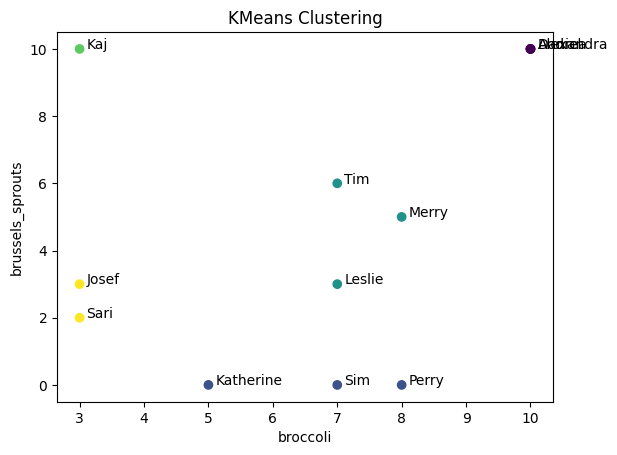

In [ ]:
"""
We intentionally placed this code within a form to ensure you stayed focused
on the main topic. However, if you’re interested in exploring Matplotlib further,
you can ask ChatGPT to explain the code line by line, ensuring you understand
everything being used here. There are also plenty of free courses and YouTube
videos available on Matplotlib.

Our suggestion, though, is not to attempt to learn everything about Matplotlib
in one go — you’ll likely forget most of it and end up googling for answers like
the rest of us. Instead, adopt a curious mindset. When you encounter Matplotlib
code, take the time to examine and understand it, but don’t linger. Over time,
this approach helps you gradually discover what’s possible with Matplotlib and
develop your intuition.
"""

# @title Visualisation of data points and clusters

# Plot the data points
plt.scatter(x = two_features_df.iloc[:, 0],
            y = two_features_df.iloc[:, 1],
            c = my_2d_kmeans.labels_,
            cmap = 'viridis')

# Annotate the data points
for idx, row in two_features_df.iterrows():
    plt.annotate(idx, (row["broccoli"], row["brussels_sprouts"]), xytext=(5, 0), textcoords='offset points')

# Add labels and title
plt.title('KMeans Clustering')
plt.xlabel(two_features_df.columns[0])
plt.ylabel(two_features_df.columns[1])

# Display the plot
plt.show()

By including the cluster centers in the plot, we can gain a clearer understanding of the data distribution.
> The annotations are omitted here to avoid clutter

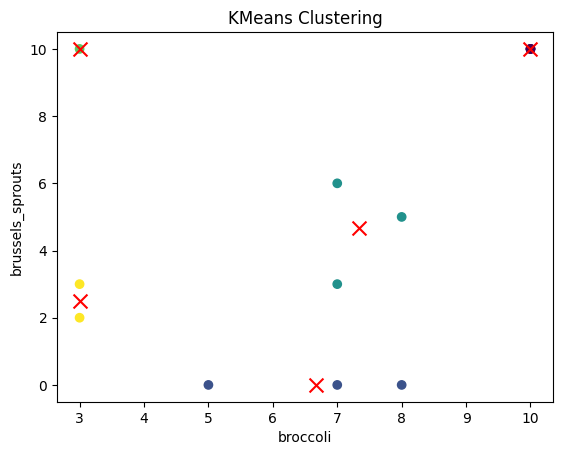

In [ ]:
"""
We intentionally placed this code within a form to ensure you stayed focused
on the main topic. However, if you’re interested in exploring Matplotlib further,
you can ask ChatGPT to explain the code line by line, ensuring you understand
everything being used here. There are also plenty of free courses and YouTube
videos available on Matplotlib.

Our suggestion, though, is not to attempt to learn everything about Matplotlib
in one go — you’ll likely forget most of it and end up googling for answers like
the rest of us. Instead, adopt a curious mindset. When you encounter Matplotlib
code, take the time to examine and understand it, but don’t linger. Over time,
this approach helps you gradually discover what’s possible with Matplotlib and
develop your intuition.
"""

# @title Clusters and centroids

# Plot the data points
plt.scatter(x = two_features_df.iloc[:, 0],
            y = two_features_df.iloc[:, 1],
            c = my_2d_kmeans.labels_,
            cmap = 'viridis')

# Plot the cluster centers
plt.scatter(x = my_2d_kmeans.cluster_centers_[:, 0],
            y = my_2d_kmeans.cluster_centers_[:, 1],
            c = 'red',
            marker = 'x',
            s = 100)

# Add labels and title
plt.title('KMeans Clustering')
plt.xlabel(two_features_df.columns[0])
plt.ylabel(two_features_df.columns[1])

# Display the plot
plt.show()

If we label all the data points, our visualisation will become cluttered.  Therefore, we should explore this data in tabular form to see who was seated next to whom at lunch, based on their preferences for broccoli and Brussels sprouts.

In [ ]:
# obtain the cluster output
table = my_2d_kmeans.labels_

# attach the cluster output to our original DataFrame
two_features_df["table"] = table

two_features_df.sort_values(by="table")

,broccoli,brussels_sprouts,table
student,,,
Alexandra,10,10,0
Andrea,10,10,0
Daniel,10,10,0
Katherine,5,0,1
Perry,8,0,1
Sim,7,0,1
Leslie,7,3,2
Merry,8,5,2
Tim,7,6,2


---
## 4.&nbsp; How does k-means find the centroids ❌

K-means clustering is an iterative algorithm that tries to partition a dataset into K pre-defined distinct non-overlapping subgroups (clusters) where each data point belongs to only one group. The algorithm minimises the distance between data points within a cluster and maximises the distance between data points in different clusters.

Steps:

1. Specify the number of clusters, K.
2. Select K points at random to act as the centroids of the clusters.
3. Assign each data point to the closest centroid.
4. Compute new centroids for each cluster by moving the centroid to the center of the data points assigned to that cluster.
5. Repeat steps 3 and 4 until the centroids no longer change.

[This website](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/) is great for showing how k-means clusters and re-clusters. Please take a look and play around.

---
## 5.&nbsp; Clustering in multiple dimensions 🔀

Having explored K-Means clustering in two dimensions for visual clarity, let's now tackle the more general scenario: high-dimensional data. Here, the intuitive plotting techniques used in two dimensions become impractical.

In [ ]:
# initialize the model
my_full_kmeans = KMeans(n_clusters = 5, # we'll explore how to choose the number of clusters in a later notebook
                        random_state = random_seed)

# fit the model to the data
my_full_kmeans.fit(foods_df)

# obtain the cluster output
table = my_full_kmeans.labels_

# attach the cluster output to our original DataFrame
foods_df["table"] = table

foods_df.sort_values(by="table")

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,broccoli,brussels_sprouts,hamburger (meat),oysters (raw),onion (raw),peas,olives,blue_cheese,whisky,table
student,,,,,,,,,,
Leslie,7,3,3,5,3,7,7,5,1,0
Merry,8,5,0,0,2,9,8,0,4,0
Perry,8,0,5,0,0,8,4,0,0,0
Sari,3,2,0,0,7,10,6,6,7,0
Sim,7,0,0,0,3,5,7,0,2,0
Josef,3,3,9,9,5,5,8,10,7,1
Katherine,5,0,9,5,10,8,10,5,8,1
Daniel,10,10,10,0,3,10,10,10,10,2
Tim,7,6,8,0,0,8,10,7,3,2


Who's table have you ended up at? Look at the food ratings, why do you think that is?

---
## 6.&nbsp; Challenge: apply this to the spotify dataset 😃

### 6.1.&nbsp; Explore the 10 songs dataset

Import the 10 songs dataset into a new notebook and explore it like we did at the beginning of this notebook. Do you agree with the liveliness scores that certain songs have been given? Do you think the top 3 most danceable songs are the most danceable songs in the list? Ask questions of the data and see where it leads you.

If you're not familiar with any of the songs, look them up on YouTube or Spotify and listen to at least 30 seconds of each song to get a feel for them. Even if you're not a music expert we can all tell the difference between gangster rap and classical, right? Look at the scores given and see if they make sense with **how these songs make you feel**.

# Step 1: Explore the 10 songs dataset

In [2]:
import pandas as pd

path = "/content/drive/MyDrive/Colab Notebooks/K_means/spotify_10_songs.csv"
df = pd.read_csv(path)

df.head(10)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/K_means/spotify_10_songs.csv'

In [ ]:


# Basic statistics
df.describe()


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.633600,0.520743,3.400000,-14.029300,0.800000,0.067630,0.434652,0.331780,0.153840,0.456580,118.716000,287493.800000,3.900000
std,0.229072,0.348562,2.221111,9.217901,0.421637,0.036715,0.447731,0.428544,0.114019,0.321551,33.661904,96496.252263,0.316228
min,0.184000,0.008330,1.000000,-33.503000,0.000000,0.030700,0.003140,0.000000,0.045400,0.059800,61.494000,109800.000000,3.000000
25%,0.508250,0.189750,1.500000,-16.468250,1.000000,0.038025,0.034975,0.000417,0.105000,0.201250,108.381500,226406.750000,4.000000
50%,0.687500,0.696000,3.000000,-11.441000,1.000000,0.054550,0.279200,0.019570,0.111000,0.439500,128.663500,291486.500000,4.000000
75%,0.745750,0.794750,4.750000,-9.456000,1.000000,0.090150,0.863750,0.799250,0.115000,0.723000,140.562750,340964.750000,4.000000
max,0.949000,0.849000,8.000000,-3.383000,1.000000,0.140000,0.990000,0.913000,0.399000,0.931000,158.691000,438720.000000,4.000000


In [ ]:

# Check missing values
df.isna().sum()

,0
song_name,0
artist,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0


In [ ]:
df.columns

Index(['song_name                                                               ',
       'artist               ', 'danceability ', 'energy  ', 'key ',
       'loudness ', 'mode ', 'speechiness ', 'acousticness ',
       'instrumentalness ', 'liveness ', 'valence ', 'tempo   ',
       'duration_ms ', 'time_signature ', 'id                     ', 'html'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns

Index(['song_name', 'artist', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'id', 'html'],
      dtype='object')

# Step 2: Do liveliness scores make sense

In [ ]:
# Sort by liveness (descending)
df.sort_values("liveness", ascending=False)[
    ["song_name", "artist", "liveness"]
]

,song_name,artist,liveness
4,"Paint It, Black ...",The Rolling Stones,0.3990
5,Sultans Of Swing ...,Dire Straits,0.3300
0,My Band ...,D12,0.1160
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,Frédéric Chopin,0.1120
7,In Silence ...,Amelie Lens,0.1110
6,Space Raiders - Charlotte de Witte Remix ...,Eats Everything,0.1110
2,Águas De Março ...,Antônio Carlos Jobim,0.1050
3,The Girl From Ipanema ...,Stan Getz,0.1050
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",Johannes Brahms,0.1040
1,The Real Slim Shady ...,Eminem,0.0454


# Result:
Songs such as “Paint It Black” and “Sultans of Swing” show higher liveness values. Classical pieces have lower liveness.

# Step 3: Are the top 3 most danceable songs really the most danceable?

In [ ]:
# Top 3 danceable songs
df.sort_values("danceability", ascending=False)[
    ["song_name", "artist", "danceability"]
].head(3)

,song_name,artist,danceability
1,The Real Slim Shady ...,Eminem,0.949
0,My Band ...,D12,0.851
6,Space Raiders - Charlotte de Witte Remix ...,Eats Everything,0.749


# Result:
The top three danceable songs are rhythm-driven hip-hop and electronic tracks. So they contain strong and regular beats suitable for dancing.

# Step 4: High energy but low valence (energetic but dark)

In [ ]:
df.sort_values(["energy", "valence"], ascending=[False, True])[
    ["song_name", "energy", "valence"]
]

,song_name,energy,valence
0,My Band ...,0.84900,0.8440
7,In Silence ...,0.84500,0.1980
4,"Paint It, Black ...",0.79500,0.6120
5,Sultans Of Swing ...,0.79400,0.9310
6,Space Raiders - Charlotte de Witte Remix ...,0.73100,0.0598
1,The Real Slim Shady ...,0.66100,0.7600
2,Águas De Março ...,0.33900,0.4910
3,The Girl From Ipanema ...,0.14000,0.3880
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,0.04510,0.0710
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",0.00833,0.2110


# Most acoustic songs

In [ ]:
df.sort_values("acousticness", ascending=False)[
    ["song_name", "acousticness", "energy"]
]

,song_name,acousticness,energy
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,0.99000,0.04510
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",0.98900,0.00833
3,The Girl From Ipanema ...,0.86700,0.14000
2,Águas De Março ...,0.85400,0.33900
0,My Band ...,0.49700,0.84900
5,Sultans Of Swing ...,0.06140,0.79400
4,"Paint It, Black ...",0.04930,0.79500
1,The Real Slim Shady ...,0.03020,0.66100
7,In Silence ...,0.00548,0.84500
6,Space Raiders - Charlotte de Witte Remix ...,0.00314,0.73100


### 6.2 Explore the dataset in dimensions
Change the code above in the section `Clustering in 2 dimensions` and re-cluster the data using different columns. Explore what happens with different pairs of columns. Why do people change tables? How different does the data look each time?

# Danceability vs Energy

In [ ]:
# 1. Create a small dataframe with only 2 dimensions
two_features_df = df[["danceability", "energy"]].copy()

two_features_df

# 2. Import model
from sklearn.cluster import KMeans

# 3. Initialise model
random_seed = 123

my_2d_kmeans = KMeans(
    n_clusters=3,
    random_state=random_seed
)

# 4. Fit model
my_2d_kmeans.fit(two_features_df)

KMeans(n_clusters=3, random_state=123)

In [ ]:
# 5. See cluster labels
two_features_df["cluster"] = my_2d_kmeans.labels_

two_features_df

,danceability,energy,cluster
0,0.851,0.84900,0
1,0.949,0.66100,0
2,0.642,0.33900,1
3,0.641,0.14000,1
4,0.464,0.79500,0
5,0.733,0.79400,0
6,0.749,0.73100,0
7,0.736,0.84500,0
8,0.184,0.00833,2
9,0.387,0.04510,2


# Result:
Here I grouped the songs based solely on:
danceability and energy

Usually:

Rap and high-energy rock songs come together
Classics are separated

# Acousticness vs Instrumentalness

In [ ]:
two_features_df = df[["acousticness", "instrumentalness"]].copy()

two_features_df

my_2d_kmeans = KMeans(
    n_clusters=3,
    random_state=random_seed
)

my_2d_kmeans.fit(two_features_df)

two_features_df["cluster"] = my_2d_kmeans.labels_

two_features_df

,acousticness,instrumentalness,cluster
0,0.49700,0.000002,2
1,0.03020,0.000000,2
2,0.85400,0.000000,1
3,0.86700,0.001660,1
4,0.04930,0.002440,2
5,0.06140,0.036700,2
6,0.00314,0.867000,0
7,0.00548,0.901000,0
8,0.98900,0.596000,1
9,0.99000,0.913000,1


# Result:
Classical songs have high acoustic

Instrumental songs have high

Pop/rap songs have low acoustic

So the clusters change completely.

# Valence vs Energy

In [ ]:
two_features_df = df[["valence", "energy"]].copy()

my_2d_kmeans = KMeans(
    n_clusters=3,
    random_state=random_seed
)

my_2d_kmeans.fit(two_features_df)

two_features_df["cluster"] = my_2d_kmeans.labels_

two_features_df

,valence,energy,cluster
0,0.8440,0.84900,2
1,0.7600,0.66100,2
2,0.4910,0.33900,1
3,0.3880,0.14000,1
4,0.6120,0.79500,2
5,0.9310,0.79400,2
6,0.0598,0.73100,0
7,0.1980,0.84500,0
8,0.2110,0.00833,1
9,0.0710,0.04510,1


# Why do people change tables (dimensions)?

## Answer:

We change the columns because clustering only looks at the features we give it.
If we choose different features, we are basically telling the model to look at the music from a different angle.
So the idea of “similar songs” changes depending on what characteristics we focus on.

# How different does the data look each time?

## Answer:

The clusters change depending on the chosen features. Some songs that were grouped together in one pair of dimensions may be separated when different features are used.

### 6.3.&nbsp; Use KMeans to group the 10 songs dataset

Play around with the clustering algorithm and get familiar with it. What happens when you change the number of clusters? What number of clusters produces the best output? What happens when you change the number of the random seed?

# Step 1: Select features (multiple numeric columns)

In [ ]:
# Select some numeric features for clustering
features_df = df[[
    "danceability",
    "energy",
    "valence",
    "tempo",
    "acousticness"
]].copy()

features_df

,danceability,energy,valence,tempo,acousticness
0,0.851,0.84900,0.8440,120.014,0.49700
1,0.949,0.66100,0.7600,104.504,0.03020
2,0.642,0.33900,0.4910,143.418,0.85400
3,0.641,0.14000,0.3880,129.318,0.86700
4,0.464,0.79500,0.6120,158.691,0.04930
5,0.733,0.79400,0.9310,148.174,0.06140
6,0.749,0.73100,0.0598,131.997,0.00314
7,0.736,0.84500,0.1980,128.009,0.00548
8,0.184,0.00833,0.2110,61.541,0.98900
9,0.387,0.04510,0.0710,61.494,0.99000


# Step 2: K_Means: k = 3

In [ ]:
from sklearn.cluster import KMeans

random_seed = 123

my_kmeans = KMeans(
    n_clusters=3,
    random_state=random_seed
)

my_kmeans.fit(features_df)


# Add cluster labels to original dataframe
df["cluster"] = my_kmeans.labels_

df[["song_name", "artist", "cluster"]].sort_values("cluster")

,song_name,artist,cluster
0,My Band ...,D12,0
1,The Real Slim Shady ...,Eminem,0
3,The Girl From Ipanema ...,Stan Getz,0
7,In Silence ...,Amelie Lens,0
6,Space Raiders - Charlotte de Witte Remix ...,Eats Everything,0
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",Johannes Brahms,1
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,Frédéric Chopin,1
2,Águas De Março ...,Antônio Carlos Jobim,2
4,"Paint It, Black ...",The Rolling Stones,2
5,Sultans Of Swing ...,Dire Straits,2


# Q1: What happens when I change the number of clusters?
## (Different k tests)

In [ ]:
for k in [2, 3, 4, 5, 6]:

    model = KMeans(n_clusters=k, random_state=123)
    model.fit(features_df)

    print("k =", k)
    print(model.labels_)
    print("-------------")

k = 2
[0 0 0 0 0 0 0 0 1 1]
-------------
k = 3
[0 0 2 0 2 2 0 0 1 1]
-------------
k = 4
[0 3 2 0 2 2 0 0 1 1]
-------------
k = 5
[4 3 2 0 2 2 0 0 1 1]
-------------
k = 6
[4 3 2 0 5 2 0 0 1 1]
-------------


# Result: Simple analysis

k = 2 → only creates two large groups (e.g. classical vs. all others)

k = 3 → usually classical/rock/pop are separated

k = 4 or 5 → some clusters become too small (because we only have 10 songs)

## Since the dataset is small, large k causes over-splitting.

# Q2: What number of clusters produces the best output?
## Answer:
In this 10-song dataset:

Usually k = 3 makes more sense

Why?

One cluster for classical

One cluster for rock

One cluster for hip-hop/pop

If I take k = 5:

Some clusters have only 1 song → it doesn't make sense

# Q3: What happens when you change the random seed?

In [ ]:
for seed in [0, 1, 45, 123]:

    model = KMeans(n_clusters=3, random_state=seed)
    model.fit(features_df)

    print("seed =", seed)
    print(model.labels_)
    print("-------------")

seed = 0
[2 2 0 0 0 0 0 0 1 1]
-------------
seed = 1
[2 2 0 2 0 0 2 2 1 1]
-------------
seed = 45
[1 1 2 1 2 2 1 1 0 0]
-------------
seed = 123
[0 0 2 0 2 2 0 0 1 1]
-------------


# Answer:
Changing the random seed may slightly change the grouping, because KMeans starts from random initial points.
However, the overall structure usually remains similar.

(Point: If k changes, the problem changes and the clusters change.
But the seed only controls the starting point, not the number of clusters.)

### 6.4.&nbsp; Familiarise yourself with the documentation for scikit-learn

We'll be using scikit-learn a lot in the coming weeks, so it's a good idea to start familiarising yourself with its documentation now. The documentation is very well written, so be sure to check it out, start with the [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) function that we used in this notebook. Play around with it and read up on some of the parameters that we didn't use.

# 1: init

In [ ]:
from sklearn.cluster import KMeans

# choose 2 columns (simple for beginners)
X = df[["danceability", "energy"]]

# 1) init = k-means++
km1 = KMeans(n_clusters=3, init="k-means++", random_state=42)
labels1 = km1.fit_predict(X)

# 2) init = random
km2 = KMeans(n_clusters=3, init="random", random_state=42)
labels2 = km2.fit_predict(X)

print("k-means++ labels:", labels1)
print("random labels   :", labels2)

k-means++ labels: [1 2 0 0 1 1 1 1 0 0]
random labels   : [2 2 0 0 2 2 2 2 1 1]


In [ ]:
print("Inertia k-means++:", km1.inertia_)
print("Inertia random   :", km2.inertia_)

Inertia k-means++: 0.305368972675
Inertia random   : 0.19907634978333327


# Result:
##  Less inertia = better clustering

# 2: n_init

In [ ]:
kmeans_low = KMeans(n_clusters=3, random_state=42, n_init=1)
kmeans_high = KMeans(n_clusters=3, random_state=42, n_init=50)

kmeans_low.fit(X)
kmeans_high.fit(X)

print("Inertia (n_init=1):", kmeans_low.inertia_)
print("Inertia (n_init=50):", kmeans_high.inertia_)

Inertia (n_init=1): 0.305368972675
Inertia (n_init=50): 0.19907634978333327


# Result:
## Larger n_init →  lower inertia → better result

### 6.5. [Optional bonus] See if you can learn to plot in 3 dimensions
Matplotlib allows you to visualise your data in 3D. Get creative and explore how to create a 3D scatter plot using different combinations of three columns from the food DataFrame. Once you have your data, experiment with clustering and assigning distinct colours to each cluster.

Compare the resulting clusters to those obtained using a 2D scatter plot. Does adding a third dimension significantly alter how the data points group together?

For an even more immersive experience, consider using Plotly, a Python library that enables interactive 3D scatter plots. Hovering your mouse over a data point in these plots reveals valuable information, such as the row index and cluster number.